# Amazon Delivery Datasets

## Configuração

In [1]:
# carregamento de bibliotecas
import sys
import os
# Adiciona a pasta raiz do projeto (onde está a pasta src) ao sys.path
sys.path.append(os.path.abspath(os.path.join("..")))
# comando autoreload dos módulos de funções
%load_ext autoreload
%autoreload 2
from src.config.logging_config import setup_logging
from src.data.load_data import carregar_dataset
from src.data.processing import *
from src.data.visualize import *

In [2]:
# configurações de logging
setup_logging()

## Análise

### Exploração Inicial

In [3]:
# carregamento dos dados
tbl_amazon_dlv = carregar_dataset('../data/raw/amazon_delivery.csv',sep=',')

2025-09-02 00:49:59,002 | INFO | src.data.load_data | Captura do arquivo no path:../data/raw/amazon_delivery.csv


In [4]:
# amostragem dos dados do dataset listings
amostra_dados(tbl_amazon_dlv)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
2673,cyci952506356,31,4.7,13.058616,80.264151,13.088616,80.294151,2022-03-05,22:10:00,22:15:00,Sandstorms,Low,scooter,Metropolitian,140,Skincare
27668,voog815786366,28,4.9,13.054347,80.257221,13.104347,80.307221,2022-03-07,23:40:00,23:55:00,Cloudy,Low,motorcycle,Urban,95,Kitchen
16473,clln702602804,28,4.5,19.091458,72.827808,19.171458,72.907808,2022-04-06,18:55:00,19:00:00,Sunny,Medium,motorcycle,Metropolitian,65,Home


**Presença de dados nulos no dataset inicial.**<br>

**Dados temporais:**<br>
** Order_Date no formato datetime (yyyy-mm--dd) no formato texto, como uma coluna.**
** Order_Time e Pickup_time no fomato hora (hh:mm:ss) no formato texto.

In [5]:
# informações do dataset tbl_amazon_dlv
tbl_amazon_dlv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


**Verificação do Intervalo de data**

**Identificação de Valores nulos**<br>
Agent_age e Weather concentram os valores nulos do dataset.
Temos 145 linhas contendo a combinação de valores nulos.
Nulos representam 20% da feature weather, enquanto Agent_Rating represrnta 12%

In [6]:
# verificação de nulos
verificacao_nulos(df=tbl_amazon_dlv)

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [7]:
# frequência de nulos
frequencia_valores_nulos(df=tbl_amazon_dlv)

,missing,total,percent
Weather,91,43739,0.208052
Agent_Rating,54,43739,0.123460
Agent_Age,0,43739,0.000000
Order_ID,0,43739,0.000000
Store_Longitude,0,43739,0.000000
Drop_Latitude,0,43739,0.000000
Drop_Longitude,0,43739,0.000000
Store_Latitude,0,43739,0.000000
Order_Date,0,43739,0.000000
Order_Time,0,43739,0.000000


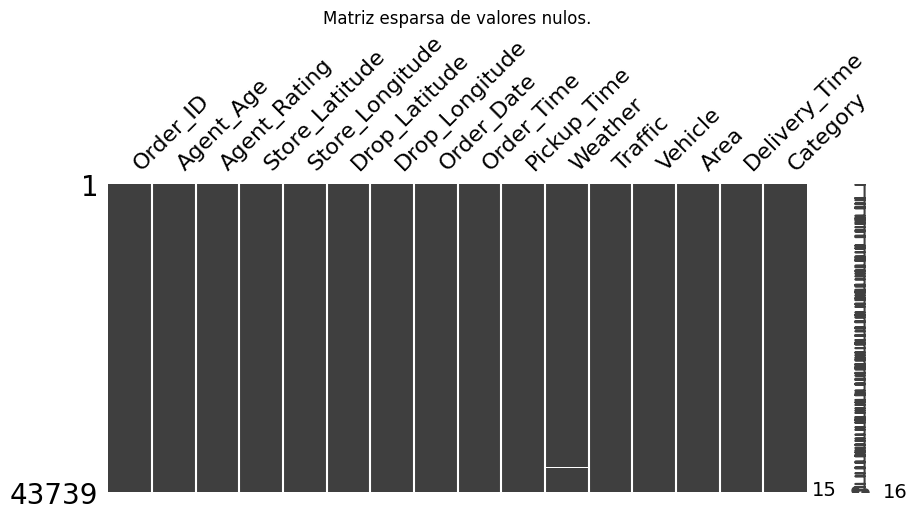

In [8]:
# matriz de linhas nulas
matriz_valores_nulos(df=tbl_amazon_dlv)

In [9]:
# filtragem das linhas com valores nulos
filtrar_linhas_valores_nulos(df=tbl_amazon_dlv)

2025-09-02 00:50:00,247 | INFO | src.data.processing | Contagem de linhas nulas para o dataframe:145


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
124,uurs547552548,23,NaN,22.569358,88.433452,22.599358,88.463452,2022-02-17,23:25:00,23:35:00,Sunny,Low,motorcycle,Metropolitian,75,Snacks
1996,xoaj834389107,32,NaN,0.000000,0.000000,0.050000,0.050000,2022-02-11,20:50:00,21:00:00,Sandstorms,Jam,motorcycle,Urban,185,Snacks
2002,lasr795083832,23,NaN,25.454648,81.834502,25.584648,81.964502,2022-02-18,19:50:00,19:55:00,Windy,Jam,motorcycle,Metropolitian,150,Outdoors
2018,gjcr517387117,26,NaN,0.000000,0.000000,0.080000,0.080000,2022-02-16,23:50:00,23:55:00,Cloudy,Low,scooter,Metropolitian,140,Clothing
2286,xige084493792,15,1.0,-26.891191,75.802083,26.981191,75.892083,2022-03-12,NaN,17:20:00,NaN,NaN,motorcycle,Urban,75,Home
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41504,ogxf318978500,20,NaN,25.451517,81.832616,25.501517,81.882616,2022-02-13,22:15:00,22:30:00,Stormy,Low,scooter,Urban,85,Shoes
42598,llox673359294,15,1.0,0.000000,0.000000,0.070000,0.070000,2022-03-14,NaN,17:40:00,NaN,NaN,scooter,Metropolitian,170,Jewelry
43027,qhka163034669,20,NaN,22.514585,88.393310,22.594585,88.473310,2022-02-14,22:20:00,22:25:00,Fog,Low,scooter,Metropolitian,100,Electronics
43053,ifig993965994,15,1.0,13.086438,80.220672,13.216439,80.350672,2022-03-18,NaN,18:00:00,NaN,NaN,van,Urban,130,Jewelry


**Verificação de linhas duplicadas**<br>
Tecnicamente o dataset corresponde a um pedido exclusivo, validado pela quantidade de pedidos para cada id. Espera-se que o id seja exclusivo para cada pedido. 

In [10]:
# verificação de linhas duplicadas
verificar_linhas_duplicadas(df=tbl_amazon_dlv)

,,,,,,,,,,,,,,,,n_duplicates
Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,


In [11]:
qtde_pedido_por_id = tbl_amazon_dlv.Order_ID.value_counts()
set(qtde_pedido_por_id)

{1}

**Dados categorizados que não apresentam ordenação**<br>
Alta quantidade de categorias para feature Category: esparcidade dos dados e necessidade de aplicar um target encoder.
Equilíbrio na frequência por categoria.

In [12]:
# contagem de categoria de produtos
qtde_pedidos_por_categoria = tbl_amazon_dlv.Category.value_counts()
qtde_pedidos_por_categoria

Category
Electronics     2849
Books           2824
Jewelry         2802
Toys            2781
Skincare        2772
Snacks          2770
Outdoors        2747
Apparel         2726
Sports          2719
Grocery         2691
Pet Supplies    2690
Home            2685
Cosmetics       2677
Kitchen         2673
Clothing        2667
Shoes           2666
Name: count, dtype: int64

In [13]:
# quantidade de pedidos por condição de tempo
qtde_pedidos_por_clima = tbl_amazon_dlv.Weather.value_counts()
qtde_pedidos_por_clima

Weather
Fog           7440
Stormy        7374
Cloudy        7288
Sandstorms    7245
Windy         7223
Sunny         7078
Name: count, dtype: int64

In [14]:
# quantidade de pedidos por condição de tempo
qtde_pedidos_por_transito = tbl_amazon_dlv.Traffic.value_counts()
qtde_pedidos_por_transito

Traffic
Low        14999
Jam        13725
Medium     10628
High        4296
NaN           91
Name: count, dtype: int64

In [15]:
# quantidade de pedidos por condição de tempo
qtde_pedidos_por_clima = tbl_amazon_dlv.Weather.value_counts()
qtde_pedidos_por_clima

Weather
Fog           7440
Stormy        7374
Cloudy        7288
Sandstorms    7245
Windy         7223
Sunny         7078
Name: count, dtype: int64

In [16]:
# quantidade de pedidos por condição de tempo
qtde_pedidos_por_clima = tbl_amazon_dlv.Weather.value_counts()
qtde_pedidos_por_clima

Weather
Fog           7440
Stormy        7374
Cloudy        7288
Sandstorms    7245
Windy         7223
Sunny         7078
Name: count, dtype: int64

### Feature Engineering

**Tarefas**<br>
Tratamento dos valores temporais: transformação e criação de coluna concatenada no formato datetime.<br>
Criação de uma coluna complementar de diferença de tempo entre order time e pickup.<br>
Criação de uma coluna de distancia a partir dos dados geolocalizados da loja a residência do cliente.<br>
Tratamento de valores nulos das colunas de order time e .<br>
Aplicação de um target encoding para feature de categoria de produtos.<br>
Encoding para feature de tempo.<br>



In [17]:
# transformação do tipo de dado da coluna para o formato datetime
tbl_amazon_dlv.Order_Date = pd.to_datetime(tbl_amazon_dlv.Order_Date)

In [18]:
# transformação da coluna Order_Date em index
tbl_amazon_dlv.set_index('Order_Date', inplace=True)

In [19]:
tbl_amazon_dlv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43739 entries, 2022-03-19 to 2022-03-02
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Time       43739 non-null  object 
 8   Pickup_Time      43739 non-null  object 
 9   Weather          43648 non-null  object 
 10  Traffic          43739 non-null  object 
 11  Vehicle          43739 non-null  object 
 12  Area             43739 non-null  object 
 13  Delivery_Time    43739 non-null  int64  
 14  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(8)
memory usage: 5.3+ MB


### Hipóteses e Insights

** Hipótese de normalidade e distribuição dos dados.

** Hipótese: média do tempo de entrega é diferente entre as categorias**

** Hipótese: média do tempo de entrega para um transito ruim é menor que a média dos demais dias**

In [ ]:
tbl_amazon_dlv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43739 entries, 2022-03-19 to 2022-03-02
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Time       43739 non-null  object 
 8   Pickup_Time      43739 non-null  object 
 9   Weather          43648 non-null  object 
 10  Traffic          43739 non-null  object 
 11  Vehicle          43739 non-null  object 
 12  Area             43739 non-null  object 
 13  Delivery_Time    43739 non-null  int64  
 14  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(8)
memory usage: 5.3+ MB


In [24]:
# analise do volume de pedidos por data
volume_pedidos_dia = agrupar_dados(df=tbl_amazon_dlv, cols_agrup=[tbl_amazon_dlv.index, 'Weather'], cols_filter=['Order_ID'], agr='count').reset_index()
volume_pedidos_dia.set_index('Order_Date', inplace=True)

2025-09-02 00:52:29,174 | INFO | src.data.processing | Agrupamento selecionado: [DatetimeIndex(['2022-03-19', '2022-03-25', '2022-03-19', '2022-04-05',
               '2022-03-26', '2022-03-11', '2022-03-04', '2022-03-14',
               '2022-03-20', '2022-02-12',
               ...
               '2022-03-18', '2022-04-05', '2022-02-14', '2022-03-30',
               '2022-03-08', '2022-03-24', '2022-02-16', '2022-03-11',
               '2022-03-07', '2022-03-02'],
              dtype='datetime64[ns]', name='Order_Date', length=43739, freq=None), 'Weather'], filtragem dataset:['Order_ID'], método: count


In [25]:
volume_pedidos_dia.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 264 entries, 2022-02-11 to 2022-04-06
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Weather   264 non-null    object
 1   Order_ID  264 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 6.2+ KB


In [28]:
volume_pedidos_dia

,Weather,Order_ID
Order_Date,,
2022-02-11,Cloudy,143
2022-02-11,Fog,160
2022-02-11,Sandstorms,149
2022-02-11,Stormy,161
2022-02-11,Sunny,155
...,...,...
2022-04-06,Fog,141
2022-04-06,Sandstorms,141
2022-04-06,Stormy,165


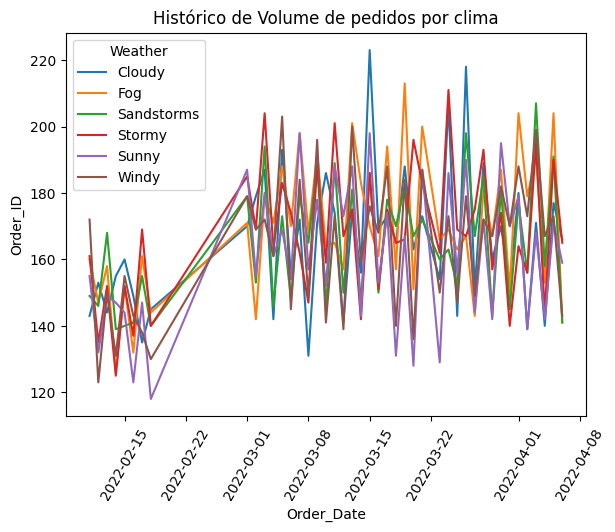

In [27]:
sns.lineplot(data=volume_pedidos_dia, x=volume_pedidos_dia.index,
             y='Order_ID',hue='Weather') 
plt.title('Histórico de Volume de pedidos por clima')
plt.tight_layout()
plt.xticks(rotation=60)
plt.show()

### Requisitos para o Pipeline